<a href="https://colab.research.google.com/github/watermelonripeness-thesis/Watermelon-Audio-Model/blob/main/eda_old_version.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# EDA: Watermelon Ripeness Audio Dataset

Ordered walkthrough: dataset overview → waveform inspection → adaptive
thump detection → noise-floor confound evidence → feature extraction →
MFCC analysis → correlation analysis → normalization check → summary.

**Key methodology note on thump detection:** rather than using a fixed
`window_after` duration, the peak/impact is detected first, then the
window is cut adaptively at the point where the signal has decayed
`DECAY_THRESHOLD_DB` (20 dB) below the peak -- i.e., where the thump has
become sparse/faded back toward the noise floor. This adapts to each
recording individually instead of assuming a fixed decay duration.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler

RIPE_DIR = "/content/drive/MyDrive/Watermelon Data/audio/ripe_orig"
UNRIPE_DIR = "/content/drive/MyDrive/Watermelon Data/audio/unripe_orig"
SR = 16000
N_MFCC = 13

MIN_SEARCH_TIME = 0.3      # skip the first 0.3s (handling noise) when looking for the peak
PRE_PADDING = 0.02          # 20ms of context before the detected peak
DECAY_THRESHOLD_DB = 20     # cut the window where the signal is 20dB below the peak
MAX_WINDOW = 0.6            # safety cap so a very slow decay doesn't run away

sns.set_style("whitegrid")

## 1. Dataset Overview

In [ ]:
def list_audio_files(folder):
    exts = (".wav", ".mp3", ".m4a", ".flac", ".ogg")
    return sorted([f for f in os.listdir(folder) if f.lower().endswith(exts)])


ripe_files = list_audio_files(RIPE_DIR)
unripe_files = list_audio_files(UNRIPE_DIR)

print(f"Ripe samples:   {len(ripe_files)}")
print(f"Unripe samples: {len(unripe_files)}")
print(f"Total:          {len(ripe_files) + len(unripe_files)}")
print(f"Class ratio (unripe:ripe): {len(unripe_files)/len(ripe_files):.2f} : 1")

Ripe samples:   154
Unripe samples: 339
Total:          493
Class ratio (unripe:ripe): 2.20 : 1


### 1.1 File-level metadata (duration, sample rate) — sanity check

Confirms no trivial artifact (e.g. one class having systematically
different clip lengths or sample rates) before any deeper analysis.

       duration_sec                        samplerate                     \
               mean       std   min    max       mean  std    min    max   
label                                                                      
ripe       1.300987  0.027471  1.28  1.376    16000.0  0.0  16000  16000   
unripe     1.316625  0.034895  1.28  1.408    16000.0  0.0  16000  16000   

       channels               
           mean  std min max  
label                         
ripe        1.0  0.0   1   1  
unripe      1.0  0.0   1   1  


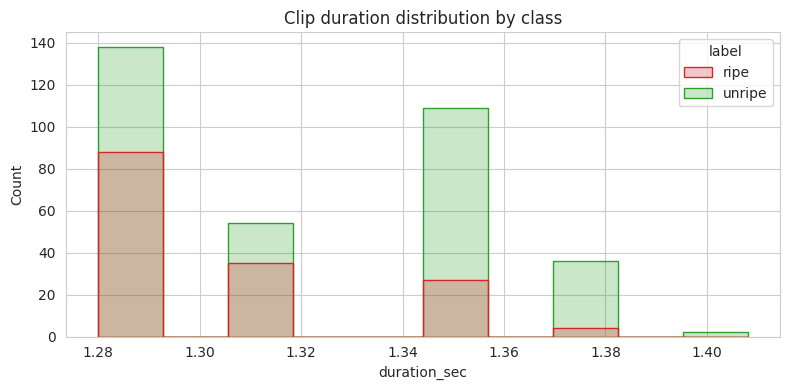

In [ ]:
import soundfile as sf

def file_metadata(folder, files, label):
    rows = []
    for fname in files:
        info = sf.info(os.path.join(folder, fname))
        rows.append({
            "filename": fname, "label": label,
            "duration_sec": info.frames / info.samplerate,
            "samplerate": info.samplerate,
            "channels": info.channels,
        })
    return pd.DataFrame(rows)

meta_df = pd.concat([
    file_metadata(RIPE_DIR, ripe_files, "ripe"),
    file_metadata(UNRIPE_DIR, unripe_files, "unripe"),
])

print(meta_df.groupby("label")[["duration_sec", "samplerate", "channels"]].agg(["mean", "std", "min", "max"]))

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=meta_df, x="duration_sec", hue="label", element="step",
             palette={"ripe": "tab:red", "unripe": "tab:green"}, ax=ax)
ax.set_title("Clip duration distribution by class")
plt.tight_layout()
plt.show()

## 2. Raw Waveform Inspection

A few representative raw waveforms per class, to see the general shape
before any processing.

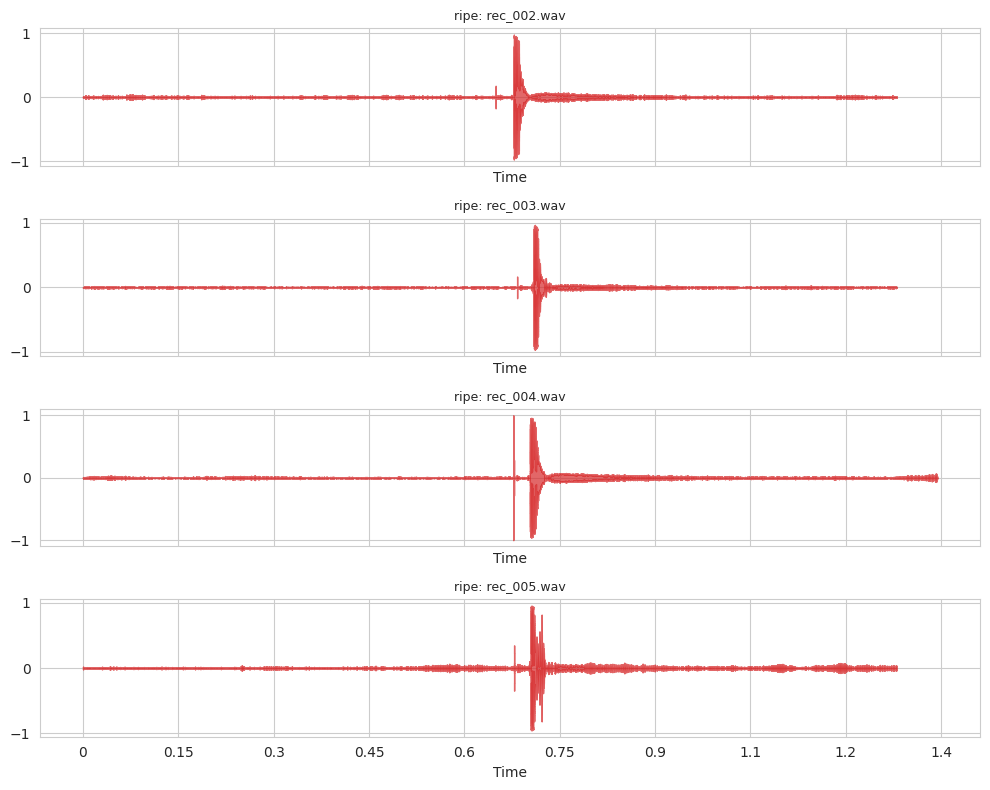

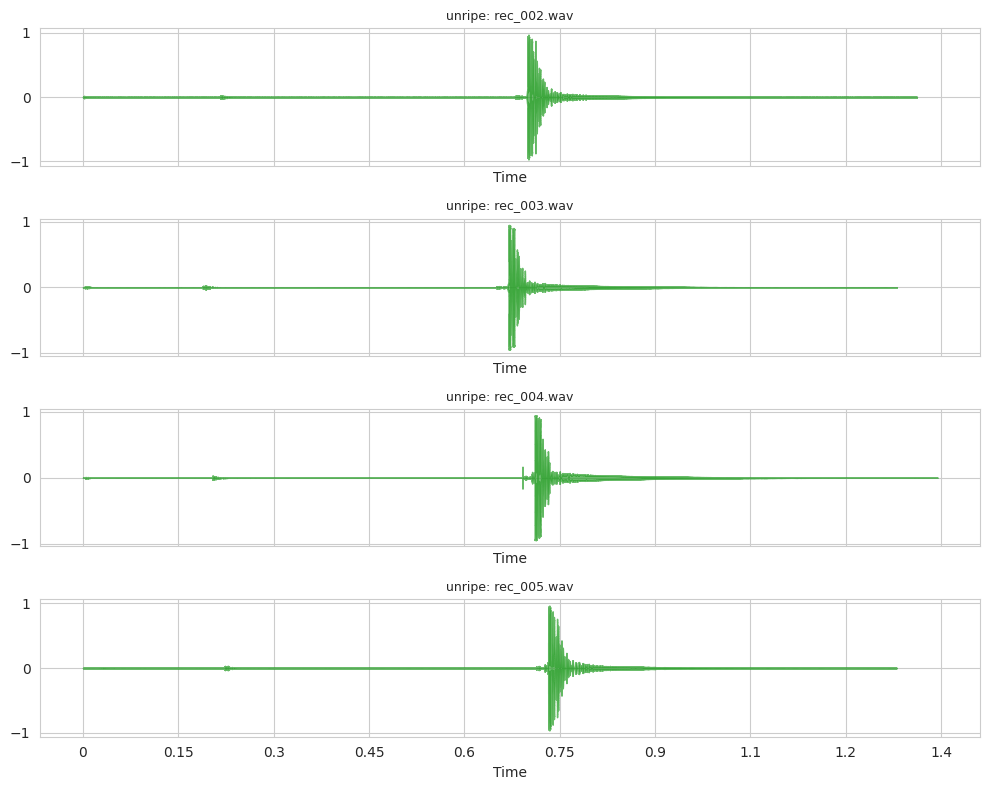

In [ ]:
def load_resampled(path, sr=SR):
    y, _ = librosa.load(path, sr=sr)
    return y


def plot_sample_waveforms(folder, files, label, n=4, sr=SR, color="tab:blue"):
    sample = files[:n]
    fig, axes = plt.subplots(n, 1, figsize=(10, 2 * n), sharex=True)
    if n == 1:
        axes = [axes]
    for ax, fname in zip(axes, sample):
        y = load_resampled(os.path.join(folder, fname), sr)
        librosa.display.waveshow(y, sr=sr, ax=ax, color=color, alpha=0.7)
        ax.set_title(f"{label}: {fname}", fontsize=9)
    plt.tight_layout()
    plt.show()

plot_sample_waveforms(RIPE_DIR, ripe_files, "ripe", n=4, color="tab:red")
plot_sample_waveforms(UNRIPE_DIR, unripe_files, "unripe", n=4, color="tab:green")

## 3. Adaptive Thump-Window Detection

Instead of a fixed `window_after` duration, the peak is located first,
then the window is cut where the signal has decayed 20dB below the
peak -- i.e. where the thump has become sparse and faded toward the
noise floor. This adapts per-recording rather than assuming every
thump decays over the same fixed duration.

In [ ]:
def rms_envelope_frames(y, sr, frame_ms=15, hop_ms=5):
    frame_len = max(int(frame_ms / 1000 * sr), 32)
    hop = max(int(hop_ms / 1000 * sr), 1)
    rms = librosa.feature.rms(y=y, frame_length=frame_len, hop_length=hop)[0]
    return rms, hop


def moving_average(x, w):
    if w <= 1 or len(x) == 0:
        return x
    kernel = np.ones(w) / w
    return np.convolve(x, kernel, mode="same")


def find_thump_window(y, sr, min_search_time=MIN_SEARCH_TIME, pre_padding=PRE_PADDING,
                       decay_threshold_db=DECAY_THRESHOLD_DB, max_window=MAX_WINDOW,
                       frame_ms=15, hop_ms=5, smooth_window=5, sustain_ms=30):
    # min_search_sample = int(min_search_time * sr)
    # search_region = y[min_search_sample:]
    # if len(search_region) == 0:
    #     return y, 0.0, len(y) / sr
    # peak_idx = np.argmax(np.abs(search_region)) + min_search_sample
    # peak_amp = np.abs(y[peak_idx])

    min_search_sample = int(min_search_time * sr)
    search_region = y[min_search_sample:]
    if len(search_region) == 0:
        return y, 0.0, len(y) / sr

    envelope_frame_len = max(int(0.016 * sr), 32)   # ~16ms
    envelope_hop = max(int(0.004 * sr), 1)            # ~4ms
    rms_env = librosa.feature.rms(y=search_region, frame_length=envelope_frame_len,
                                    hop_length=envelope_hop)[0]
    if len(rms_env) == 0:
        peak_idx = np.argmax(np.abs(search_region)) + min_search_sample
    else:
        best_frame = np.argmax(rms_env)
        frame_start = best_frame * envelope_hop
        frame_end = min(frame_start + envelope_frame_len, len(search_region))
        local_peak_offset = np.argmax(np.abs(search_region[frame_start:frame_end]))
        peak_idx = min_search_sample + frame_start + local_peak_offset

    peak_amp = np.abs(y[peak_idx])

    remaining = y[peak_idx:]
    rms, hop = rms_envelope_frames(remaining, sr, frame_ms, hop_ms)

    if len(rms) == 0 or peak_amp == 0:
        end_idx = min(len(y), peak_idx + int(max_window * sr))
    else:
        smoothed = moving_average(rms, smooth_window)
        threshold = peak_amp / (10 ** (decay_threshold_db / 20))
        sustain_frames = max(int(sustain_ms / hop_ms), 1)

        below = smoothed < threshold
        end_frame = None
        run = 0
        for i, b in enumerate(below):
            run = run + 1 if b else 0
            if run >= sustain_frames:
                end_frame = i - sustain_frames + 1
                break
        end_idx = peak_idx + end_frame * hop if end_frame is not None else len(y)
        end_idx = min(end_idx, peak_idx + int(max_window * sr))

    start_idx = max(0, peak_idx - int(pre_padding * sr))
    windowed = y[start_idx:end_idx]
    return windowed, peak_idx / sr, end_idx / sr

### 3.1 Visual check: does the adaptive window make sense?

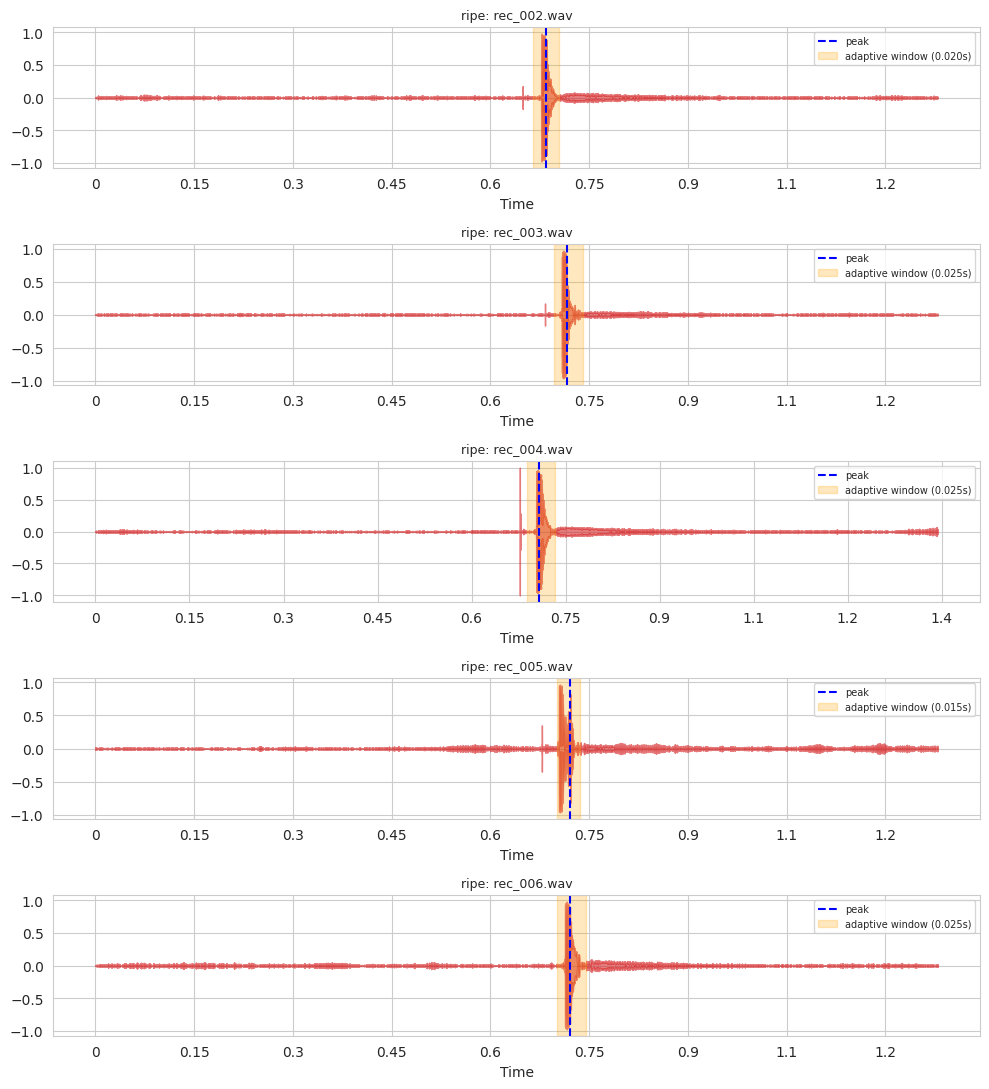

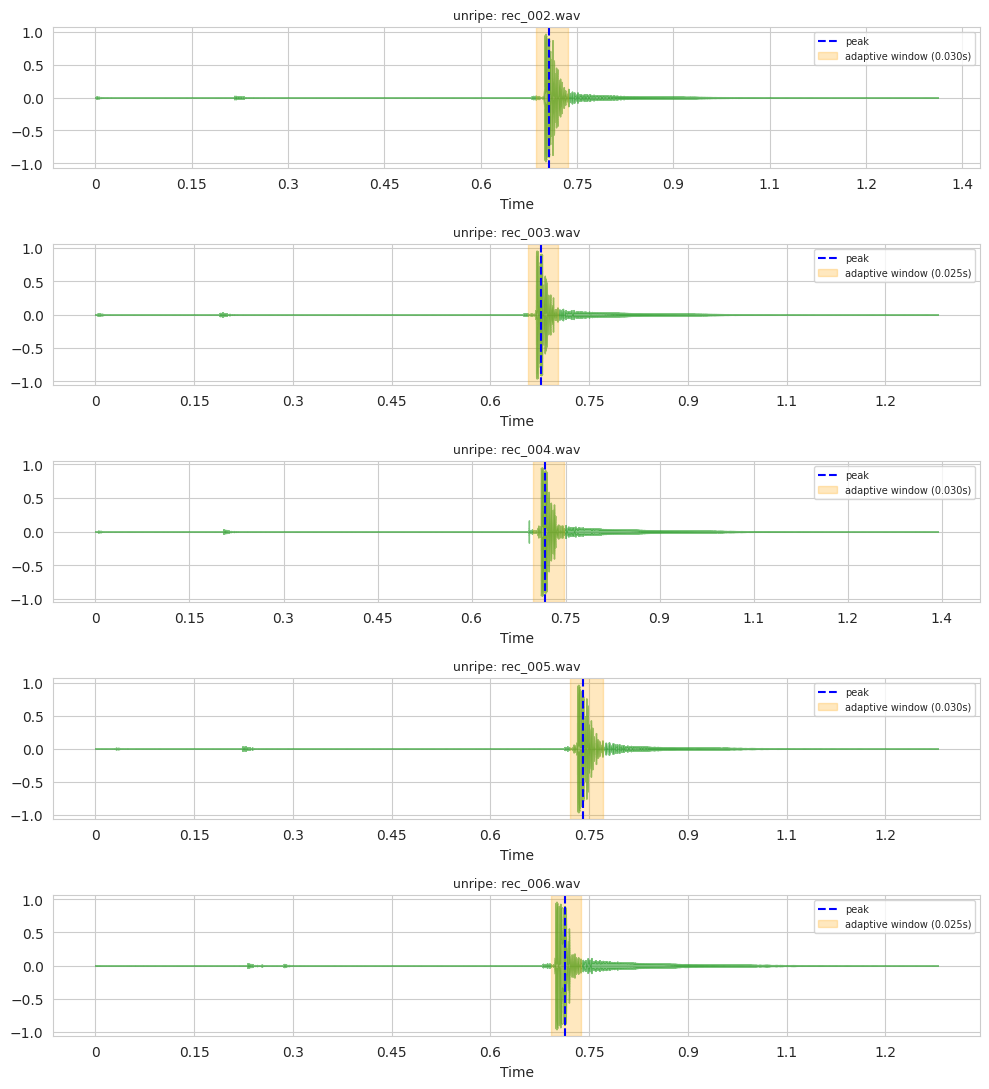

In [ ]:
def plot_adaptive_window_check(folder, files, label, n=5, sr=SR, color="tab:blue"):
    sample = files[:n]
    fig, axes = plt.subplots(n, 1, figsize=(10, 2.2 * n))
    if n == 1:
        axes = [axes]
    for ax, fname in zip(axes, sample):
        y = load_resampled(os.path.join(folder, fname), sr)
        _, peak_time, end_time = find_thump_window(y, sr)

        librosa.display.waveshow(y, sr=sr, ax=ax, alpha=0.6, color=color)
        ax.axvline(peak_time, color="blue", linestyle="--", label="peak")
        ax.axvspan(peak_time - PRE_PADDING, end_time, color="orange", alpha=0.25,
                   label=f"adaptive window ({end_time - peak_time:.3f}s)")
        ax.set_title(f"{label}: {fname}", fontsize=9)
        ax.legend(loc="upper right", fontsize=7)
    plt.tight_layout()
    plt.show()

plot_adaptive_window_check(RIPE_DIR, ripe_files, "ripe", n=5, color="tab:red")
plot_adaptive_window_check(UNRIPE_DIR, unripe_files, "unripe", n=5, color="tab:green")

### 3.2 Distribution of detected window lengths

If the adaptive method is working sensibly, window lengths should form
a reasonably tight distribution rather than being wildly erratic.

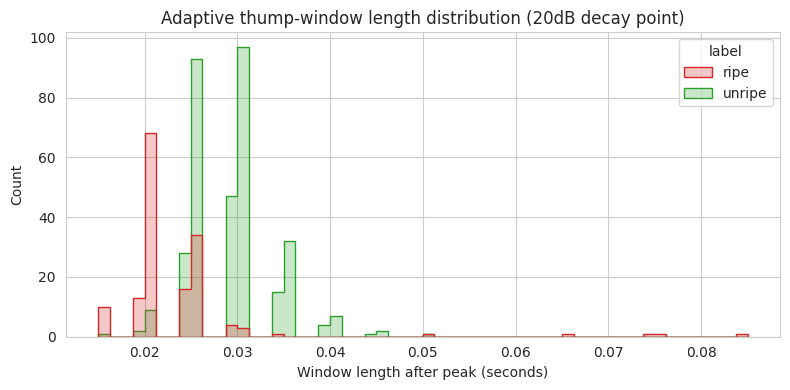


Window Stats Summary (by label)
       peak_time                                                              \
           count      mean       std       min       25%       50%       75%   
label                                                                          
ripe       154.0  0.705103  0.018911  0.677063  0.685391  0.709187  0.716672   
unripe     339.0  0.706765  0.021175  0.676250  0.684312  0.710375  0.716063   

                 window_length                                                 \
             max         count      mean       std    min    25%   50%    75%   
label                                                                           
ripe    0.781875         154.0  0.023474  0.009486  0.015  0.020  0.02  0.025   
unripe  0.784875         339.0  0.029056  0.004678  0.015  0.025  0.03  0.030   

               
          max  
label          
ripe    0.085  
unripe  0.050  

Dataframe Structure
<class 'pandas.core.frame.DataFrame'>
Index: 493 entries, 0

In [ ]:
def window_length_stats(folder, files, label, sr=SR):
    rows = []
    for fname in files:
        y = load_resampled(os.path.join(folder, fname), sr)
        _, peak_time, end_time = find_thump_window(y, sr)
        rows.append({"filename": fname, "label": label,
                     "peak_time": peak_time, "window_length": end_time - peak_time})
    return pd.DataFrame(rows)

window_stats_df = pd.concat([
    window_length_stats(RIPE_DIR, ripe_files, "ripe"),
    window_length_stats(UNRIPE_DIR, unripe_files, "unripe"),
])

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=window_stats_df, x="window_length", hue="label", element="step",
             palette={"ripe": "tab:red", "unripe": "tab:green"}, ax=ax)
ax.set_title("Adaptive thump-window length distribution (20dB decay point)")
ax.set_xlabel("Window length after peak (seconds)")
plt.tight_layout()
plt.show()

print("\nWindow Stats Summary (by label)")
print(window_stats_df.groupby("label")[["peak_time", "window_length"]].describe())

print("\nDataframe Structure")
window_stats_df.info()

## 4. Pre-Thump Noise Floor — Confound Evidence

The audio captured BEFORE the thump should contain no information about
fruit ripeness. If it correlates with the label anyway, that's strong
evidence of a recording-environment confound rather than a genuine
ripeness signal.

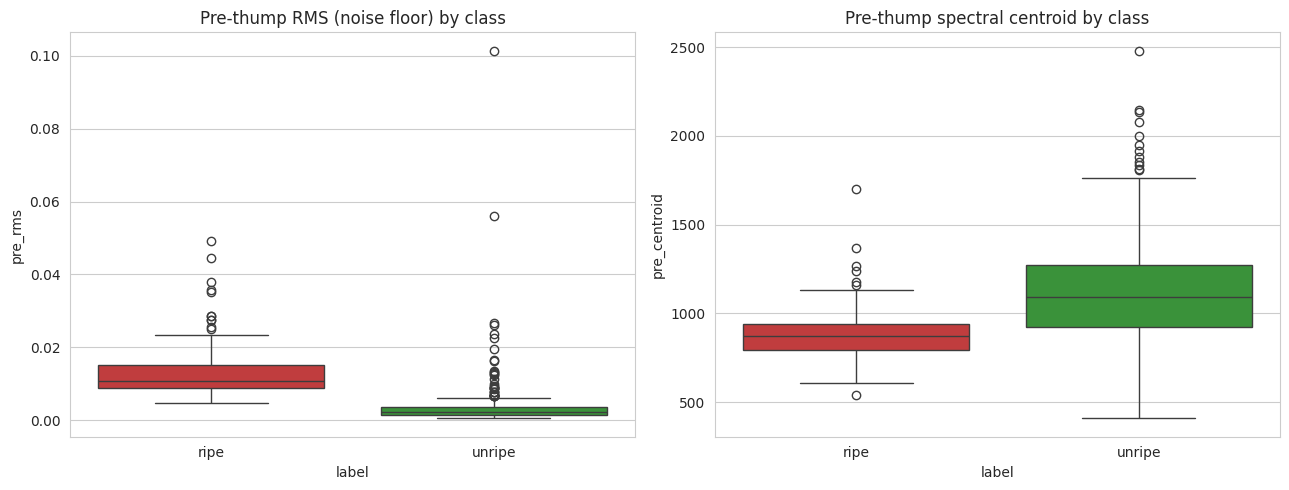

Shapiro-Wilk test
ripe - pre_rms: W=0.7579, p=1.17e-14  -> NOT normal
ripe - pre_centroid: W=0.8972, p=6.55e-09  -> NOT normal
unripe - pre_rms: W=0.2987, p=6.94e-34  -> NOT normal
unripe - pre_centroid: W=0.9693, p=1.35e-06  -> NOT normal

Pre-silence RMS, ripe vs unripe: Mann-Whitney U p-value = 5.61e-59

         pre_rms           pre_centroid            
            mean       std         mean         std
label                                              
ripe    0.013016  0.007176   886.570002  143.067794
unripe  0.003692  0.006968  1120.993632  309.539267


In [ ]:
def presilence_stats(folder, files, label, sr=SR, presilence_sec=0.15):
    rows = []
    for fname in files:
        y = load_resampled(os.path.join(folder, fname), sr)
        n = int(presilence_sec * sr)
        pre = y[:n]
        rows.append({
            "filename": fname,
            "label": label,
            "pre_rms": np.sqrt(np.mean(pre**2)) if len(pre) else np.nan,
            "pre_centroid": librosa.feature.spectral_centroid(y=pre, sr=sr).mean() if len(pre) else np.nan,
        })
    return rows

pre_rows = presilence_stats(RIPE_DIR, ripe_files, "ripe") + presilence_stats(UNRIPE_DIR, unripe_files, "unripe")
pre_df = pd.DataFrame(pre_rows)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
palette = {"ripe": "tab:red", "unripe": "tab:green"}

for ax, col, title in zip(axes, ["pre_rms", "pre_centroid"],
                           ["Pre-thump RMS (noise floor) by class", "Pre-thump spectral centroid by class"]):
    sns.boxplot(data=pre_df, x="label", y=col, hue="label", palette=palette, legend=False, ax=ax)
    ax.set_title(title)

plt.tight_layout()
plt.show()

from scipy.stats import shapiro

print("Shapiro-Wilk test")
for label, group in pre_df.groupby("label"):
    for col in ["pre_rms", "pre_centroid"]:
        stat, p = shapiro(group[col].dropna())
        verdict = "NOT normal" if p < 0.05 else "normal (fail to reject)"
        print(f"{label} - {col}: W={stat:.4f}, p={p:.2e}  -> {verdict}")
print()

# --- Mann-Whitney U comes AFTER, justified by the normality result above ---
ripe_rms = pre_df[pre_df.label == "ripe"]["pre_rms"].dropna()
unripe_rms = pre_df[pre_df.label == "unripe"]["pre_rms"].dropna()
t_stat, p_val = stats.mannwhitneyu(ripe_rms, unripe_rms)
print(f"Pre-silence RMS, ripe vs unripe: Mann-Whitney U p-value = {p_val:.2e}")
print()
print(pre_df.groupby("label")[["pre_rms", "pre_centroid"]].agg(["mean", "std"]))

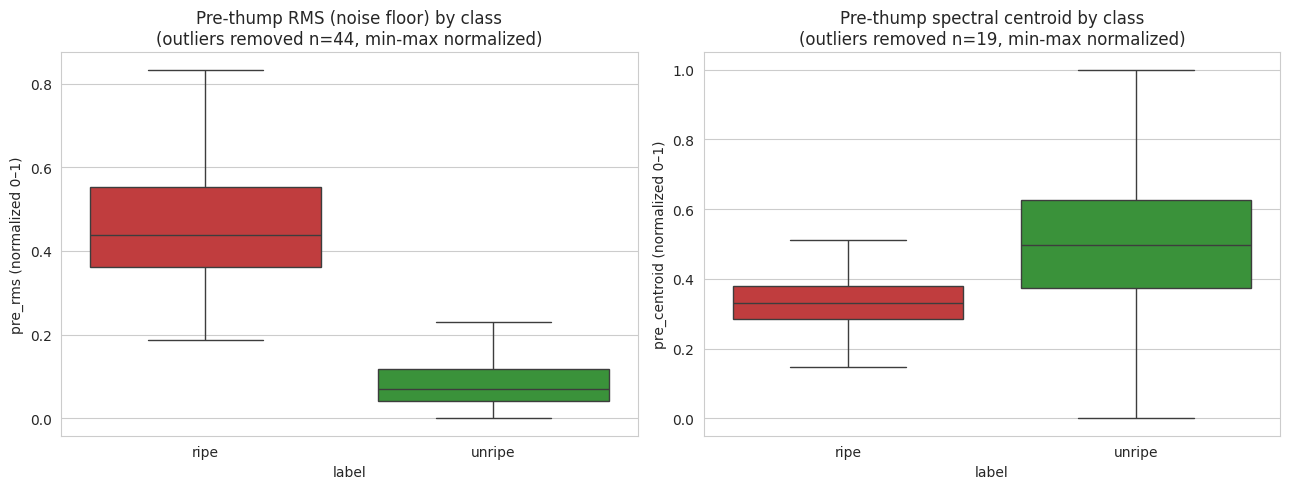

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def presilence_stats(folder, files, label, sr=SR, presilence_sec=0.15):
    rows = []
    for fname in files:
        y = load_resampled(os.path.join(folder, fname), sr)
        n = int(presilence_sec * sr)
        pre = y[:n]
        rows.append({
            "filename": fname,
            "label": label,
            "pre_rms": np.sqrt(np.mean(pre**2)) if len(pre) else np.nan,
            "pre_centroid": librosa.feature.spectral_centroid(y=pre, sr=sr).mean() if len(pre) else np.nan,
        })
    return rows

pre_rows = presilence_stats(RIPE_DIR, ripe_files, "ripe") + presilence_stats(UNRIPE_DIR, unripe_files, "unripe")
pre_df = pd.DataFrame(pre_rows)

palette = {"ripe": "tab:red", "unripe": "tab:green"}

def remove_outliers_iqr(df, col, group_col="label", k=1.5):
    filtered_parts = []
    for label, group in df.groupby(group_col):
        q1, q3 = group[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - k * iqr, q3 + k * iqr
        filtered_parts.append(group[(group[col] >= lower) & (group[col] <= upper)])
    return pd.concat(filtered_parts)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, col, title in zip(axes, ["pre_rms", "pre_centroid"],
                           ["Pre-thump RMS (noise floor) by class", "Pre-thump spectral centroid by class"]):
    # Step 1: remove outliers (IQR method, per class)
    filtered_df = remove_outliers_iqr(pre_df, col).copy()
    n_removed = len(pre_df) - len(filtered_df)

    # Step 2: normalize what's left (min-max, 0-1)
    scaler = MinMaxScaler()
    filtered_df[col] = scaler.fit_transform(filtered_df[[col]])

    sns.boxplot(data=filtered_df, x="label", y=col, hue="label", palette=palette,
                legend=False, showfliers=False, ax=ax)
    ax.set_title(f"{title}\n(outliers removed n={n_removed}, min-max normalized)")
    ax.set_ylabel(f"{col} (normalized 0\u20131)")

plt.tight_layout()
plt.show()

In [ ]:
for col in ["pre_rms", "pre_centroid"]:
    filtered_df = remove_outliers_iqr(pre_df, col)
    print(f"--- {col} ---")
    print(f"Original rows: {len(pre_df)}")
    print(f"After outlier removal: {len(filtered_df)}")
    print(filtered_df["label"].value_counts())
    print()

--- pre_rms ---
Original rows: 493
After outlier removal: 449
label
unripe    306
ripe      143
Name: count, dtype: int64

--- pre_centroid ---
Original rows: 493
After outlier removal: 474
label
unripe    327
ripe      147
Name: count, dtype: int64



**Interpretation:** the pre-thump silence — which should carry no
ripeness information — differs sharply and statistically significantly
between classes. This is evidence of a recording-environment confound,
not a fruit-related signal.

## 5. Feature Extraction (Adaptive Window)

MFCCs and spectral descriptors, extracted from the adaptively-detected
thump window (Section 3), not a fixed-duration window.

In [ ]:
def extract_features(folder, files, label, sr=SR, n_mfcc=N_MFCC):
    rows = []
    for fname in files:
        y = load_resampled(os.path.join(folder, fname), sr)
        windowed, peak_time, end_time = find_thump_window(y, sr)
        if len(windowed) < 32:
            continue

        mfcc = librosa.feature.mfcc(y=windowed, sr=sr, n_mfcc=n_mfcc)
        mfcc_means = mfcc.mean(axis=1)
        mfcc_stds = mfcc.std(axis=1)

        row = {
            "filename": fname,
            "label": label,
            "spectral_centroid": librosa.feature.spectral_centroid(y=windowed, sr=sr).mean(),
            "spectral_bandwidth": librosa.feature.spectral_bandwidth(y=windowed, sr=sr).mean(),
            "spectral_rolloff": librosa.feature.spectral_rolloff(y=windowed, sr=sr).mean(),
            "zero_crossing_rate": librosa.feature.zero_crossing_rate(windowed).mean(),
            "rms": librosa.feature.rms(y=windowed).mean(),
        }
        for i in range(n_mfcc):
            row[f"mfcc{i+1}_mean"] = mfcc_means[i]
            row[f"mfcc{i+1}_std"] = mfcc_stds[i]
        rows.append(row)
    return pd.DataFrame(rows)

features_df = pd.concat([
    extract_features(RIPE_DIR, ripe_files, "ripe"),
    extract_features(UNRIPE_DIR, unripe_files, "unripe"),
]).reset_index(drop=True)

print(f"Extracted features for {len(features_df)} files, {features_df.shape[1] - 2} features each")
features_df.head()

/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=640
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=720
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=560
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=800
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=880
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1680
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266:

Extracted features for 493 files, 31 features each


,filename,label,spectral_centroid,spectral_bandwidth,spectral_rolloff,zero_crossing_rate,rms,mfcc1_mean,mfcc1_std,mfcc2_mean,...,mfcc9_mean,mfcc9_std,mfcc10_mean,mfcc10_std,mfcc11_mean,mfcc11_std,mfcc12_mean,mfcc12_std,mfcc13_mean,mfcc13_std
0,rec_002.wav,ripe,1434.540564,1739.117760,2980.46875,0.011230,0.199167,-2.177335,2.250347,104.464691,...,10.043567,1.342926,34.897057,0.072578,14.375582,0.381746,0.761404,0.281200,-6.622787,0.137606
1,rec_003.wav,ripe,1515.653203,1481.328964,2867.18750,0.018066,0.189460,1.452865,2.212204,99.009224,...,19.381922,1.175627,35.381096,0.558098,13.622829,0.433767,7.188321,0.868149,-6.303168,1.351216
2,rec_004.wav,ripe,1381.987118,1628.861464,2917.96875,0.013184,0.218592,-1.663367,1.766999,104.619850,...,15.501369,0.860123,37.264778,1.099840,26.121967,0.584309,-3.143459,0.413248,-10.070515,0.400702
3,rec_005.wav,ripe,1119.013152,1347.224760,2144.53125,0.012695,0.205094,-8.366394,17.530865,137.837585,...,-9.005486,0.339582,-5.621066,0.367749,8.303425,2.032827,19.324978,2.419491,2.737652,2.531553
4,rec_006.wav,ripe,1252.888073,1448.265974,2535.15625,0.012207,0.210636,-6.207685,1.447920,121.114548,...,17.222122,0.144694,27.883244,0.539040,23.621099,0.255468,14.284080,0.223132,-3.074621,0.451414


## 6. MFCC Coefficient Analysis

Mean value of each MFCC coefficient (1–13), compared by class, with
error bars showing one standard deviation. Large, consistent gaps here
indicate coefficients that strongly differ between classes.

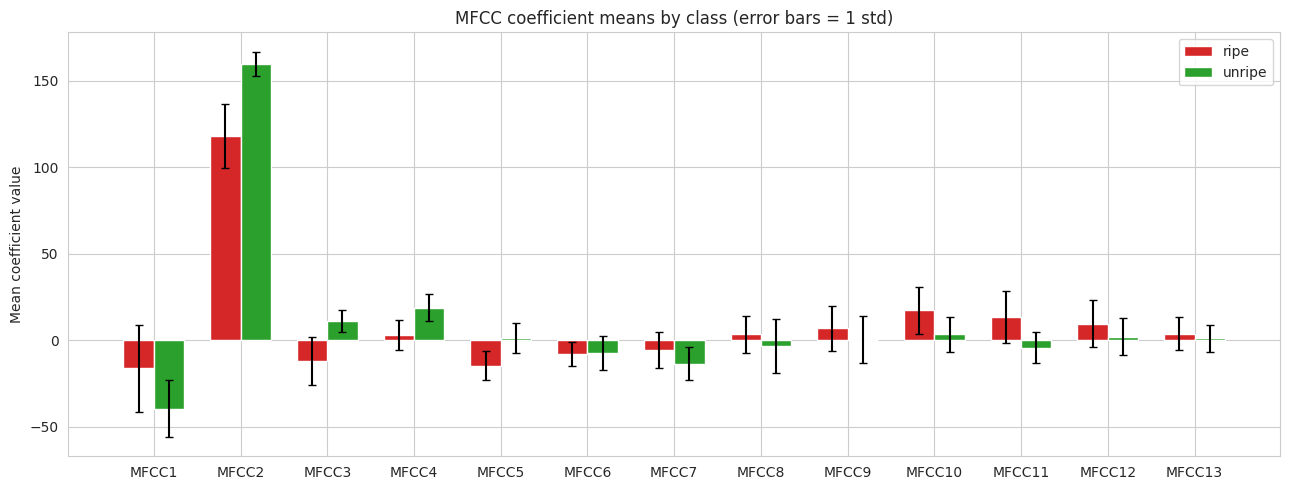

In [ ]:
mfcc_mean_cols = [f"mfcc{i+1}_mean" for i in range(N_MFCC)]

mfcc_summary = features_df.groupby("label")[mfcc_mean_cols].agg(["mean", "std"])

fig, ax = plt.subplots(figsize=(13, 5))
x = np.arange(N_MFCC)
width = 0.35

ripe_means = [mfcc_summary[(c, "mean")]["ripe"] for c in mfcc_mean_cols]
ripe_stds = [mfcc_summary[(c, "std")]["ripe"] for c in mfcc_mean_cols]
unripe_means = [mfcc_summary[(c, "mean")]["unripe"] for c in mfcc_mean_cols]
unripe_stds = [mfcc_summary[(c, "std")]["unripe"] for c in mfcc_mean_cols]

ax.bar(x - width/2, ripe_means, width, yerr=ripe_stds, label="ripe", color="tab:red", capsize=3)
ax.bar(x + width/2, unripe_means, width, yerr=unripe_stds, label="unripe", color="tab:green", capsize=3)
ax.set_xticks(x)
ax.set_xticklabels([f"MFCC{i+1}" for i in range(N_MFCC)])
ax.set_ylabel("Mean coefficient value")
ax.set_title("MFCC coefficient means by class (error bars = 1 std)")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Correlation Analysis

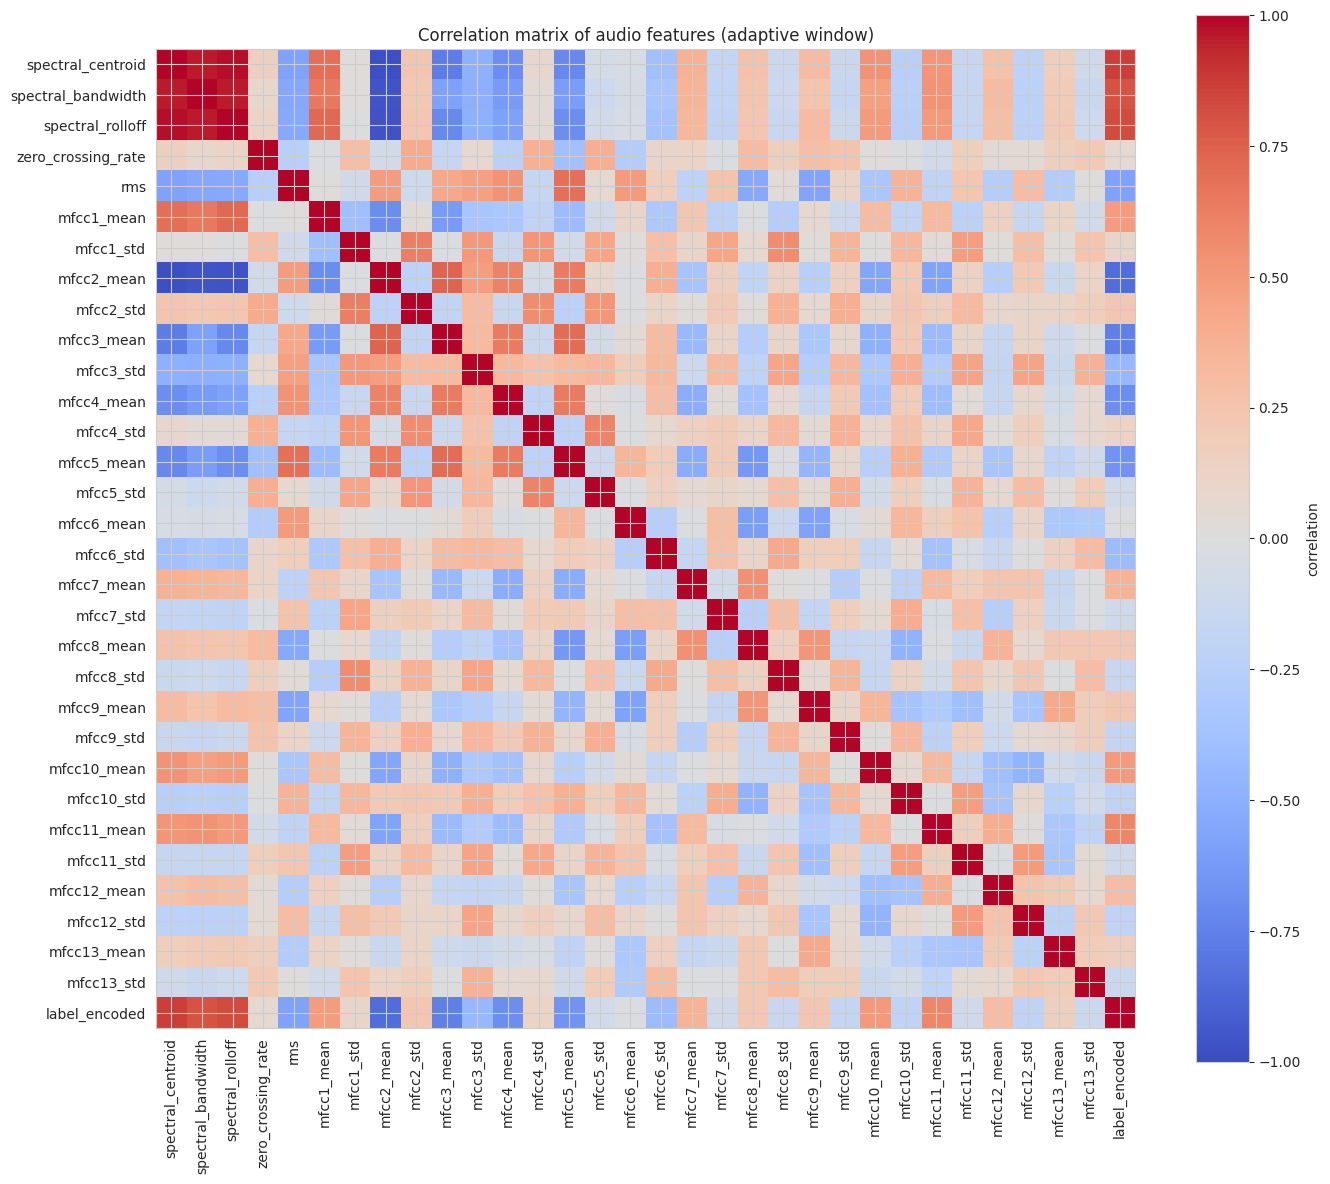

Feature correlations with label (sorted by |r|, with significance):
           Feature      r       p-value Significance
 spectral_centroid  0.865 2.994482e-149          ***
        mfcc2_mean -0.850 1.766905e-138          ***
  spectral_rolloff  0.821 1.922195e-121          ***
spectral_bandwidth  0.801 1.852696e-111          ***
        mfcc3_mean -0.754  1.356167e-91          ***
        mfcc4_mean -0.683  4.891306e-69          ***
        mfcc5_mean -0.649  2.442444e-60          ***
       mfcc11_mean  0.587  5.097442e-47          ***
               rms -0.576  6.276151e-45          ***
       mfcc10_mean  0.500  1.602272e-32          ***
        mfcc1_mean  0.483  3.025226e-30          ***
         mfcc3_std -0.439  1.165298e-24          ***
         mfcc6_std -0.410  1.979539e-21          ***
        mfcc7_mean  0.352  8.269318e-16          ***
       mfcc12_mean  0.289  6.003635e-11          ***
        mfcc9_mean  0.224  5.131185e-07          ***
         mfcc2_std  0.220  8.24

In [ ]:
from scipy.stats import pearsonr

features_df["label_encoded"] = features_df["label"].map({"unripe": 0, "ripe": 1})

corr_cols = [c for c in features_df.columns if c not in ["filename", "label"]]
corr_matrix = features_df[corr_cols].corr()

plt.figure(figsize=(14, 12))
plt.imshow(corr_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("Correlation matrix of audio features (adaptive window)")
plt.tight_layout()
plt.show()

# Proper research-table format: coefficient + significance, not just raw r
feature_cols_only = [c for c in corr_cols if c != "label_encoded"]
rows = []
for col in feature_cols_only:
    r, p = pearsonr(features_df[col], features_df["label_encoded"])
    stars = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else ""
    rows.append({"Feature": col, "r": round(r, 3), "p-value": p, "Significance": stars})

corr_table = pd.DataFrame(rows)
corr_table["abs_r"] = corr_table["r"].abs()
corr_table = corr_table.sort_values("abs_r", ascending=False).drop(columns="abs_r").reset_index(drop=True)

print("Feature correlations with label (sorted by |r|, with significance):")
print(corr_table.to_string(index=False))

In [ ]:
from scipy.stats import shapiro

print("=== Normality check: thump-period features (features_df) ===")
test_cols = ["spectral_centroid", "spectral_bandwidth", "spectral_rolloff",
             "zero_crossing_rate", "rms"] + [f"mfcc{i+1}_mean" for i in range(N_MFCC)]

normality_results = []
for label, group in features_df.groupby("label"):
    for col in test_cols:
        stat, p = shapiro(group[col].dropna())
        verdict = "NOT normal" if p < 0.05 else "normal"
        normality_results.append({"label": label, "feature": col, "W": stat, "p": p, "verdict": verdict})

normality_df = pd.DataFrame(normality_results)
print(normality_df.to_string(index=False))
print()
n_not_normal = (normality_df["verdict"] == "NOT normal").sum()
print(f"{n_not_normal} / {len(normality_df)} feature-class combinations are NOT normally distributed")

=== Normality check: thump-period features (features_df) ===
 label            feature        W            p    verdict
  ripe  spectral_centroid 0.937124 2.450233e-06 NOT normal
  ripe spectral_bandwidth 0.982701 5.057944e-02     normal
  ripe   spectral_rolloff 0.970688 2.280527e-03 NOT normal
  ripe zero_crossing_rate 0.812859 9.266972e-13 NOT normal
  ripe                rms 0.953956 5.629839e-05 NOT normal
  ripe         mfcc1_mean 0.750815 7.068302e-15 NOT normal
  ripe         mfcc2_mean 0.908580 3.000816e-08 NOT normal
  ripe         mfcc3_mean 0.994454 8.272516e-01     normal
  ripe         mfcc4_mean 0.989460 3.034582e-01     normal
  ripe         mfcc5_mean 0.972752 3.784493e-03 NOT normal
  ripe         mfcc6_mean 0.986770 1.513911e-01     normal
  ripe         mfcc7_mean 0.992780 6.347391e-01     normal
  ripe         mfcc8_mean 0.985278 1.014940e-01     normal
  ripe         mfcc9_mean 0.991756 5.172799e-01     normal
  ripe        mfcc10_mean 0.960246 2.091573e-04 NOT no

In [ ]:
corr_pearson = features_df[corr_cols].corr(method="pearson")["label_encoded"]
corr_spearman = features_df[corr_cols].corr(method="spearman")["label_encoded"]

comparison = pd.DataFrame({
    "Pearson r": corr_pearson,
    "Spearman rho": corr_spearman,
}).drop("label_encoded")
comparison["abs_pearson"] = comparison["Pearson r"].abs()
comparison = comparison.sort_values("abs_pearson", ascending=False).drop(columns="abs_pearson")

print(comparison.to_string())

                    Pearson r  Spearman rho
spectral_centroid    0.865124      0.735760
mfcc2_mean          -0.849541     -0.717247
spectral_rolloff     0.820700      0.719670
spectral_bandwidth   0.800961      0.720907
mfcc3_mean          -0.753811     -0.692276
mfcc4_mean          -0.683165     -0.666936
mfcc5_mean          -0.649231     -0.642333
mfcc11_mean          0.587187      0.537989
rms                 -0.576079     -0.634676
mfcc10_mean          0.499842      0.463475
mfcc1_mean           0.483486      0.568588
mfcc3_std           -0.439154     -0.524150
mfcc6_std           -0.410189     -0.488323
mfcc7_mean           0.351799      0.364912
mfcc12_mean          0.289128      0.254879
mfcc9_mean           0.223842      0.191375
mfcc2_std            0.219852      0.224741
mfcc8_mean           0.216323      0.263182
mfcc12_std          -0.197597     -0.228893
mfcc10_std          -0.195464     -0.210503
mfcc9_std           -0.174813     -0.218652
mfcc13_mean          0.149278   

## 8. Pairplot of Top Correlated Features (Min-Max Normalized)

Min-max scaling to [0, 1] here is purely for visual comparability across
features with very different native ranges (e.g. Hz vs. unitless
ratios). It does NOT change the correlation values above -- Pearson
correlation is scale-invariant -- it only affects how the scatter plots
look side by side.

Top 5 features: ['spectral_centroid', 'mfcc2_mean', 'spectral_rolloff', 'spectral_bandwidth', 'mfcc3_mean']

Removing 22 outlier row(s) out of 493:
   filename  label  spectral_centroid  mfcc2_mean  spectral_rolloff  spectral_bandwidth  mfcc3_mean
rec_056.wav   ripe         821.709734  161.629471       1410.156250         1207.197644    5.082241
rec_092.wav   ripe         794.693972  160.318863       1261.718750         1204.301548   20.843258
rec_103.wav   ripe        1643.464213  100.666687       3914.062500         1884.732532    5.563620
rec_111.wav   ripe         743.829202  165.871796       1208.333333         1162.165293   15.433269
rec_118.wav   ripe         729.990654  171.295822       1144.531250         1089.108319   10.468002
rec_134.wav   ripe         746.072866  177.278900       1035.156250         1079.646922   15.699358
rec_136.wav   ripe         775.604618  173.052811       1054.687500         1131.185705   19.648687
rec_139.wav   ripe         700.479158  175.440750   

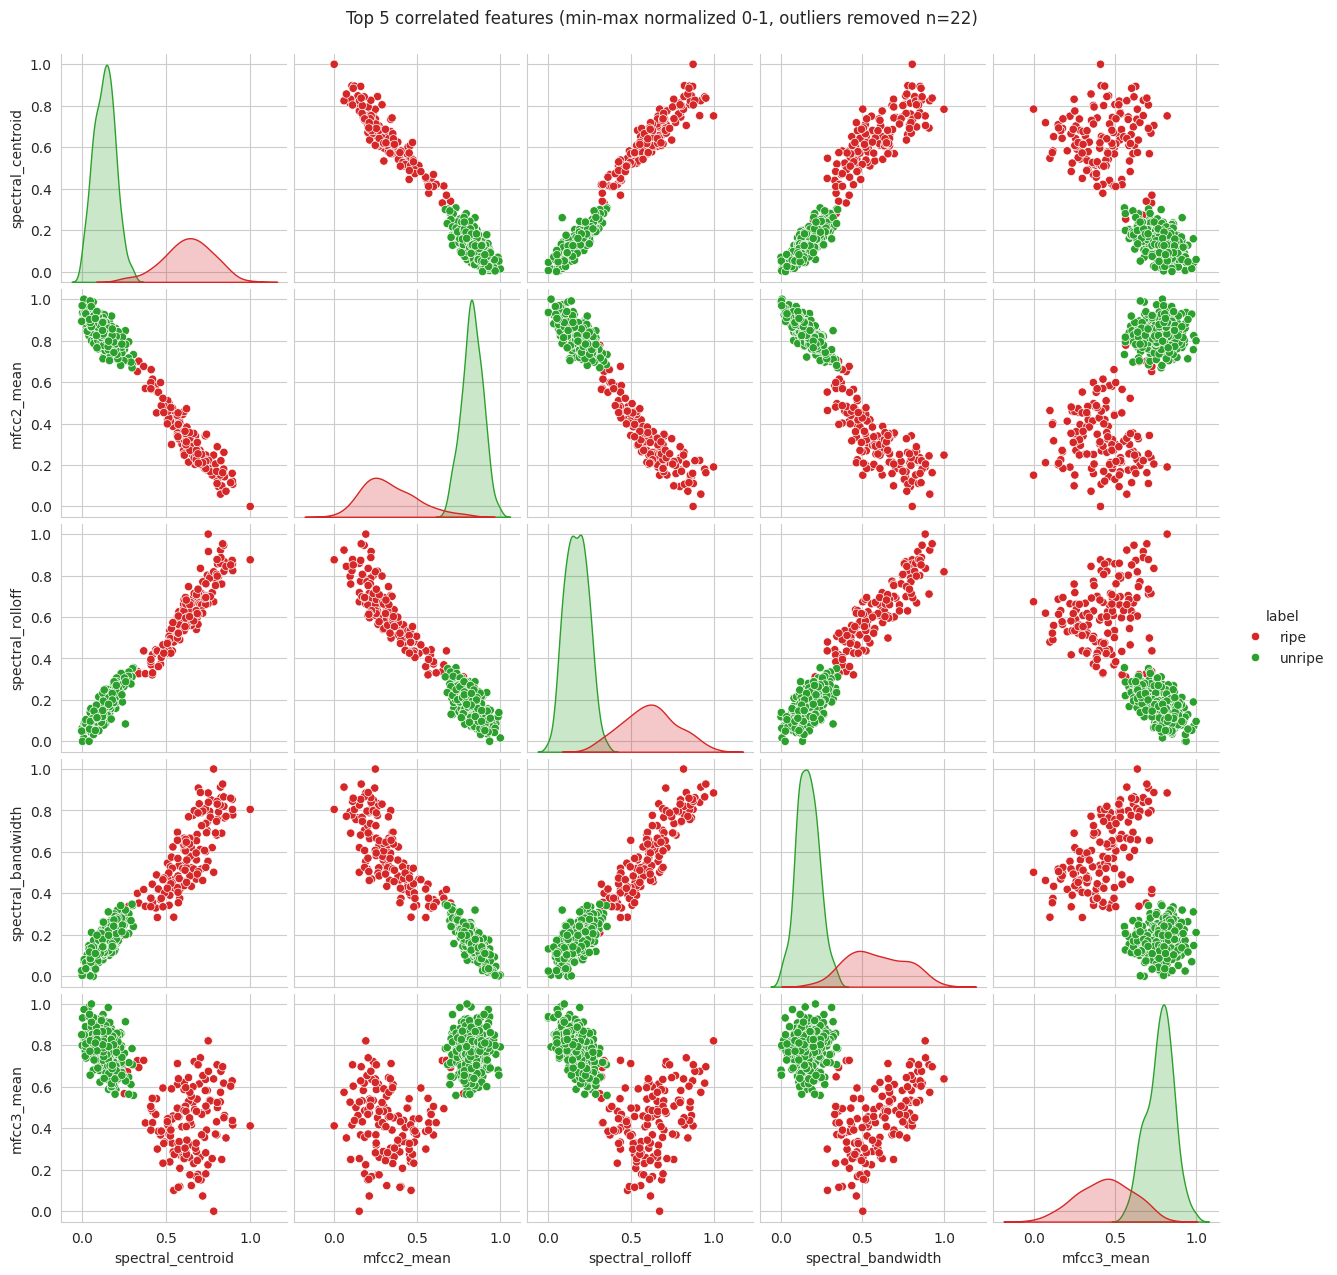

In [ ]:
top_features = corr_matrix["label_encoded"].abs().sort_values(ascending=False).index[1:6]
print("Top 5 features:", list(top_features))

plot_df = features_df.copy()

outlier_mask = pd.Series(False, index=plot_df.index)
for feature in top_features:
    for label, group in plot_df.groupby("label"):
        q1, q3 = group[feature].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        flagged = group[(group[feature] < lower) | (group[feature] > upper)].index
        outlier_mask.loc[flagged] = True

print(f"\nRemoving {outlier_mask.sum()} outlier row(s) out of {len(plot_df)}:")
print(plot_df.loc[outlier_mask, ["filename", "label"] + list(top_features)].to_string(index=False))

plot_df_clean = plot_df.loc[~outlier_mask].copy()

scaler = MinMaxScaler()
plot_df_clean[list(top_features)] = scaler.fit_transform(plot_df_clean[list(top_features)])

sns.pairplot(plot_df_clean, vars=list(top_features), hue="label", palette=palette, diag_kind="kde")
plt.suptitle(f"Top 5 correlated features (min-max normalized 0-1, outliers removed n={outlier_mask.sum()})", y=1.02)
plt.show()

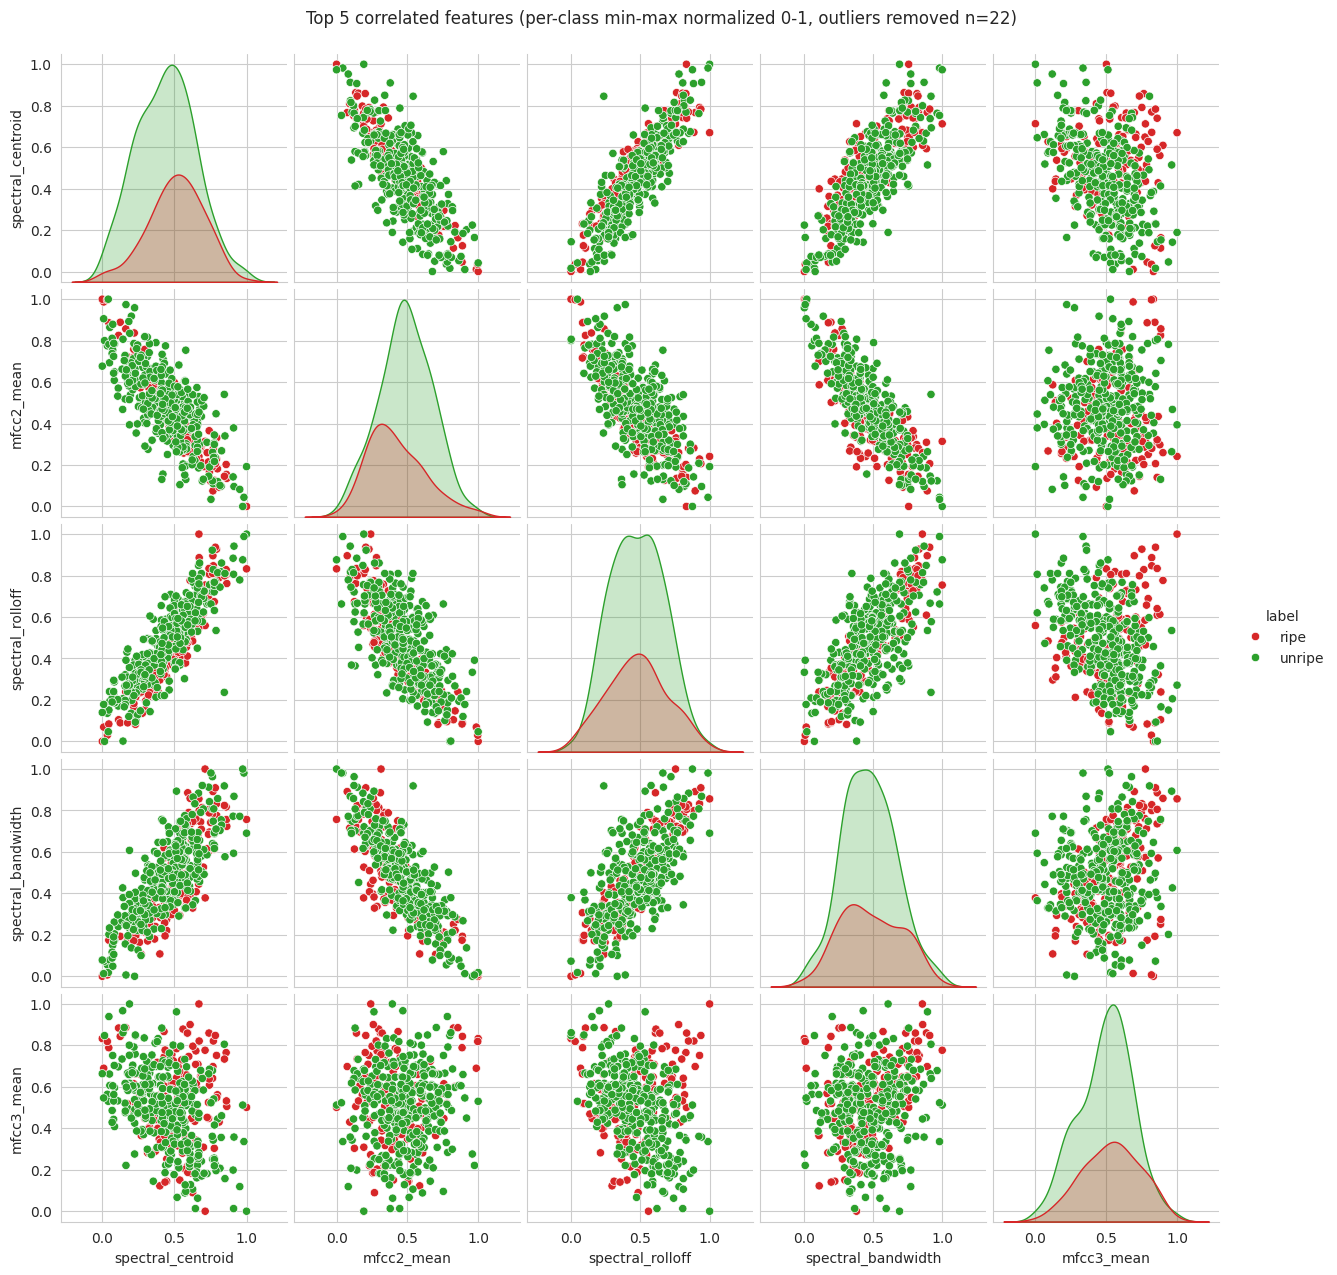

In [ ]:
plot_df_pc = plot_df.loc[~outlier_mask].copy()

parts = []
for label, group in plot_df_pc.groupby("label"):
    g = group.copy()
    g[list(top_features)] = MinMaxScaler().fit_transform(g[list(top_features)])
    parts.append(g)

plot_df_pc = pd.concat(parts).sort_index()

sns.pairplot(plot_df_pc, vars=list(top_features), hue="label", palette=palette, diag_kind="kde")
plt.suptitle(f"Top 5 correlated features (per-class min-max normalized 0-1, outliers removed n={outlier_mask.sum()})", y=1.02)
plt.show()

## 9. Waveform Amplitude Normalization Check

Tests whether normalizing each recording's own peak amplitude to 1.0
BEFORE extracting features reduces the confound. This is a different
operation from the min-max scaling above (which only rescaled finished
numbers for plotting) -- this rescales the raw audio itself, which
genuinely changes the computed MFCC/spectral values.

/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=640
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=720
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=560
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=800
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=880
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1680
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/librosa/core/spectrum.py:266:

MFCC-label correlation BEFORE amplitude normalization:
mfcc2_mean     0.849541
mfcc3_mean     0.753811
mfcc4_mean     0.683165
mfcc5_mean     0.649231
mfcc11_mean    0.587187
Name: label_encoded, dtype: float64

MFCC-label correlation AFTER amplitude normalization:
mfcc2_mean     0.849541
mfcc3_mean     0.753811
mfcc4_mean     0.683165
mfcc5_mean     0.649231
mfcc11_mean    0.587187
Name: label_encoded, dtype: float64


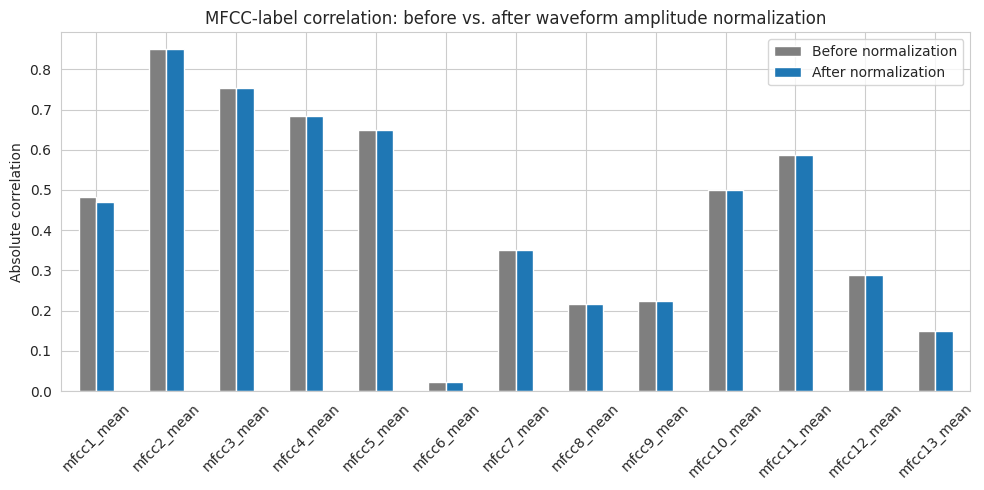

In [ ]:
def extract_features_amplitude_normalized(folder, files, label, sr=SR, n_mfcc=N_MFCC):
    rows = []
    for fname in files:
        y = load_resampled(os.path.join(folder, fname), sr)
        windowed, peak_time, end_time = find_thump_window(y, sr)
        if len(windowed) < 32:
            continue

        peak = np.max(np.abs(windowed))
        if peak > 0:
            windowed = windowed / peak

        mfcc = librosa.feature.mfcc(y=windowed, sr=sr, n_mfcc=n_mfcc)
        mfcc_means = mfcc.mean(axis=1)

        row = {"filename": fname, "label": label}
        for i in range(n_mfcc):
            row[f"mfcc{i+1}_mean"] = mfcc_means[i]
        rows.append(row)
    return pd.DataFrame(rows)

features_df_amp_norm = pd.concat([
    extract_features_amplitude_normalized(RIPE_DIR, ripe_files, "ripe"),
    extract_features_amplitude_normalized(UNRIPE_DIR, unripe_files, "unripe"),
]).reset_index(drop=True)

features_df_amp_norm["label_encoded"] = features_df_amp_norm["label"].map({"unripe": 0, "ripe": 1})
mfcc_cols_only = [c for c in features_df_amp_norm.columns if c.startswith("mfcc")]
corr_amp_norm = features_df_amp_norm[mfcc_cols_only + ["label_encoded"]].corr()["label_encoded"].drop("label_encoded")

print("MFCC-label correlation BEFORE amplitude normalization:")
print(corr_matrix["label_encoded"][mfcc_cols_only].abs().sort_values(ascending=False).head(5))
print()
print("MFCC-label correlation AFTER amplitude normalization:")
print(corr_amp_norm.abs().sort_values(ascending=False).head(5))

fig, ax = plt.subplots(figsize=(10, 5))
comparison = pd.DataFrame({
    "Before normalization": corr_matrix["label_encoded"][mfcc_cols_only].abs(),
    "After normalization": corr_amp_norm.abs(),
})
comparison.plot(kind="bar", ax=ax, color=["tab:gray", "tab:blue"])
ax.set_title("MFCC-label correlation: before vs. after waveform amplitude normalization")
ax.set_ylabel("Absolute correlation")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 10. Summary of EDA Findings

- The dataset's two classes were recorded in different physical
  environments (market for ripe, farm for unripe).
- Pre-thump silence — which should carry no ripeness information —
  differs sharply and significantly between classes (Mann-Whitney U
  test, printed above), indicating a recording-environment confound.
- Several MFCC coefficients correlate strongly with the label (see
  Section 7), consistent with that confound rather than genuine
  ripeness signal.
- Amplitude normalization (Section 9) reduces but does not eliminate
  this correlation, indicating the confound is not purely a loudness/
  gain artifact.
- These findings motivate the feature-engineering approach used in the
  main preprocessing pipeline (resonance modeling, amplitude exclusion)
  documented separately.

In [ ]:
print("=" * 70)
print("EDA SUMMARY")
print("=" * 70)
print(f"Total samples: {len(features_df)} (ripe: {(features_df.label=='ripe').sum()}, "
      f"unripe: {(features_df.label=='unripe').sum()})")
print(f"Pre-silence RMS Mann-Whitney U p-value: {p_val:.2e}")
print(f"Top correlated feature with label: "
      f"{corr_matrix['label_encoded'].abs().sort_values(ascending=False).index[1]} "
      f"({corr_matrix['label_encoded'].abs().sort_values(ascending=False).iloc[1]:.3f})")
print(f"Mean MFCC-label correlation before amplitude normalization: "
      f"{corr_matrix['label_encoded'][mfcc_cols_only].abs().mean():.3f}")
print(f"Mean MFCC-label correlation after amplitude normalization: "
      f"{corr_amp_norm.abs().mean():.3f}")
print("=" * 70)

EDA SUMMARY
Total samples: 493 (ripe: 154, unripe: 339)
Pre-silence RMS Mann-Whitney U p-value: 5.61e-59
Top correlated feature with label: spectral_centroid (0.865)
Mean MFCC-label correlation before amplitude normalization: 0.443
Mean MFCC-label correlation after amplitude normalization: 0.442
